[I 2025-02-19 07:25:36,682] A new study created in memory with name: no-name-6b2a4ac9-d798-4dc3-9684-42b0563e5662
[I 2025-02-19 07:25:45,608] Trial 0 finished with value: 0.9919592078994226 and parameters: {'max_depth': 4, 'learning_rate': 0.07707143709091621, 'n_estimators': 146, 'min_child_weight': 4, 'reg_lambda': 1.7146716303851797, 'reg_alpha': 0.27014387507152154}. Best is trial 0 with value: 0.9919592078994226.
[I 2025-02-19 07:25:49,271] Trial 1 finished with value: 0.9934236227270274 and parameters: {'max_depth': 5, 'learning_rate': 0.16500664770930143, 'n_estimators': 202, 'min_child_weight': 5, 'reg_lambda': 0.5977457321617897, 'reg_alpha': 1.606962992342582}. Best is trial 1 with value: 0.9934236227270274.
[I 2025-02-19 07:25:53,008] Trial 2 finished with value: 0.9936394539470135 and parameters: {'max_depth': 9, 'learning_rate': 0.09669829498997873, 'n_estimators': 286, 'min_child_weight': 4, 'reg_lambda': 0.18109556394214443, 'reg_alpha': 1.6691808762460791}. Best is tria

XGBoost: ROC AUC = 0.9949
[LightGBM] [Info] Number of positive: 2153, number of negative: 2152
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4992
[LightGBM] [Info] Number of data points in the train set: 4305, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500116 -> initscore=0.000465
[LightGBM] [Info] Start training from score 0.000465
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

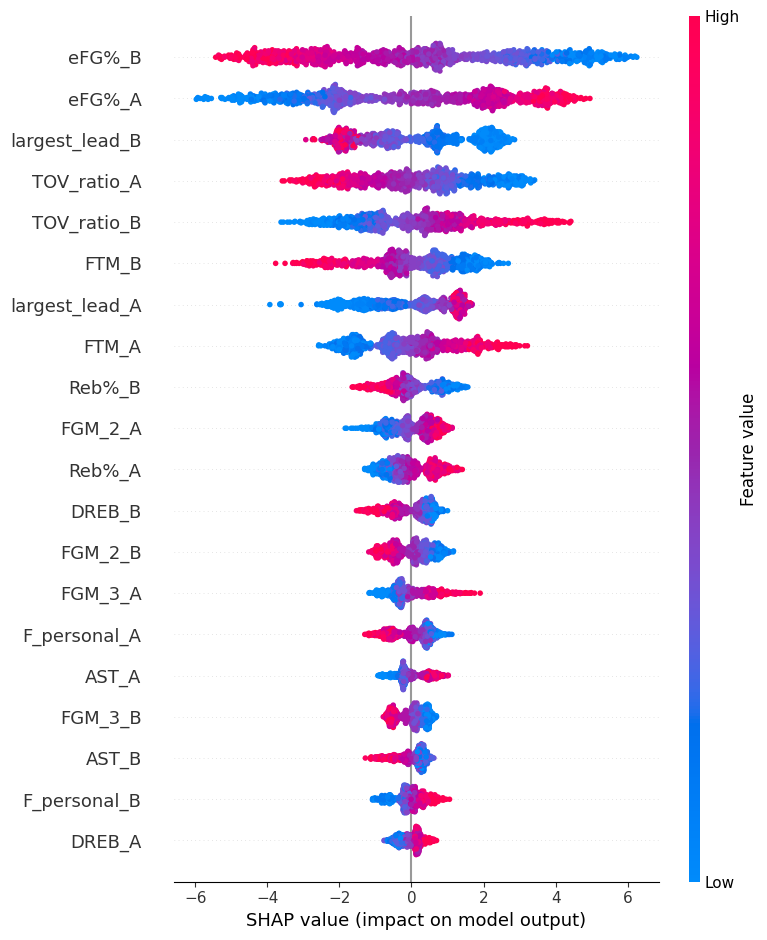

   Team_A_Probability  Team_B_Probability Predicted_Winner
0            0.000031            0.999969           Team B
1            0.000747            0.999253           Team B
2            0.299992            0.700008           Team B
3            0.999999            0.000001           Team A
4            0.998312            0.001688           Team A
5            0.000289            0.999711           Team B
6            0.001099            0.998901           Team B
7            0.000012            0.999988           Team B
8            0.999803            0.000197           Team A
9            0.020716            0.979284           Team B
Best Model: XGBClassifier with ROC AUC = 0.9949


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE

# Load dataset
file_path = 'games_merged_corrected.csv'  # Change this to your actual file path
df = pd.read_csv(file_path)

# Fill NaN values with column medians (numeric only)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Create target variable
df['Winner'] = (df['Score_A'] > df['Score_B']).astype(int)

# Feature Engineering (Handling potential division errors)
eps = 1e-9  # Small epsilon to prevent division by zero
df['eFG%_A'] = (df['FGM_2_A'] + 1.5 * df['FGM_3_A']) / (df['FGA_2_A'] + df['FGA_3_A'] + eps)
df['eFG%_B'] = (df['FGM_2_B'] + 1.5 * df['FGM_3_B']) / (df['FGA_2_B'] + df['FGA_3_B'] + eps)
df['TOV_ratio_A'] = df['TOV_A'] / (df['FGA_2_A'] + df['FGA_3_A'] + df['FTA_A'] + df['TOV_A'] + eps)
df['TOV_ratio_B'] = df['TOV_B'] / (df['FGA_2_B'] + df['FGA_3_B'] + df['FTA_B'] + df['TOV_B'] + eps)
df['Reb%_A'] = df['OREB_A'] / (df['OREB_A'] + df['DREB_B'] + eps)
df['Reb%_B'] = df['OREB_B'] / (df['OREB_B'] + df['DREB_A'] + eps)

# Prepare features and target
features = [col for col in df.columns if col not in ['Score_A', 'Score_B', 'Winner']]
X = df[features]
y = df['Winner']

# Handle class imbalance with SMOTE
X, y = SMOTE(random_state=42).fit_resample(X, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Bayesian Optimization for XGBoost
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2.0),
        'tree_method': 'hist',
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    model = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
best_params = study.best_params

# Define models with optimized hyperparameters
models = {
    "XGBoost": xgb.XGBClassifier(**best_params),
    "LightGBM": lgb.LGBMClassifier(max_depth=4, num_leaves=20, min_child_samples=30, reg_lambda=1.2, reg_alpha=0.6),
    "CatBoost": cb.CatBoostClassifier(verbose=0, depth=5, l2_leaf_reg=3.0),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=10, min_samples_leaf=5, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=5000, solver='saga', C=0.7, penalty='l2')
}

# Train and evaluate models
best_model, best_score = None, 0
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    print(f"{name}: ROC AUC = {auc:.4f}")
    if auc > best_score:
        best_model, best_score = model, auc

# Feature Importance with SHAP (for best model)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# Predicting outcomes
y_pred_proba = best_model.predict_proba(X_test)

# Convert probabilities into readable output
predictions_df = pd.DataFrame({
    "Team_A_Probability": y_pred_proba[:, 1],
    "Team_B_Probability": y_pred_proba[:, 0],
    "Predicted_Winner": ["Team A" if prob > 0.5 else "Team B" for prob in y_pred_proba[:, 1]]
})

# Print predictions
print(predictions_df.head(10))  # Show top 10 predictions

# Save predictions to CSV
predictions_df.to_csv("predicted_winners.csv", index=False)

# Print best model
print(f"Best Model: {best_model.__class__.__name__} with ROC AUC = {best_score:.4f}")